# RQ3: Do language markers of nightmare context predict higher symptoms?

This notebook tests whether nightmare-related language in dream reports predicts higher PHQ-9 and GAD-7 symptom scores.
Predictors: lexicon-based nightmare content + embedding-based nightmare intensity.
Outcomes: `phq_total`, `gad_total`.

## 0. Setup
- Assumes `integrated_dream_data.csv` in project root.
- Install packages if missing: `pip install pandas scikit-learn sentence-transformers` (optional for embeddings).

In [32]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_absolute_error

# Embedding model is optional; code falls back to lexicon-only intensity
try:
    from sentence_transformers import SentenceTransformer
    import torch

    EMBEDDING_AVAILABLE = True
except Exception:
    SentenceTransformer = None
    EMBEDDING_AVAILABLE = False

pd.set_option("display.max_colwidth", 120)

DATA_PATH = Path("Upd Integration") / "integrated_dream_data_1.csv"

## 1. Load & tidy data
- Keep rows with non-empty dream text (>=20 chars).
- Remove generic "no dream" placeholders.
- Normalize scores to numeric.

In [33]:
raw = pd.read_csv(DATA_PATH)
print("raw shape:", raw.shape)

raw["dream_text"] = raw["dream_text"].astype(str).str.strip()
raw = raw[raw["dream_text"].notna() & raw["dream_text"].str.len().ge(20)].copy()

raw["phq_total"] = pd.to_numeric(raw["phq_total"], errors="coerce")
raw["gad_total"] = pd.to_numeric(raw["gad_total"], errors="coerce")
raw = raw.dropna(subset=["phq_total", "gad_total"])
print("after filters:", raw.shape)
raw[["dream_text", "phq_total", "gad_total"]].head()

raw shape: (9841, 24)
after filters: (9841, 24)


,dream_text,phq_total,gad_total
0,No dreams that I remember,3.0,0.0
1,I don't remember dreams,13.0,7.0
2,"I had a dream that my old cats were still alive. They were getting old and had cat Alzheimer's in my dream, but they...",17.0,9.0
3,I dreamt I encountered someone from my past. We embraced and I felt joy at reconnecting,13.0,14.0
4,I had a couple nightmare dreams,9.0,9.0


In [34]:
raw["phq_total"].describe(), raw["gad_total"].describe()

(count    9841.000000
 mean        7.707347
 std         5.604741
 min         0.000000
 25%         3.000000
 50%         7.000000
 75%        11.000000
 max        27.000000
 Name: phq_total, dtype: float64,
 count    9841.000000
 mean        6.884158
 std         4.930987
 min         0.000000
 25%         3.000000
 50%         6.000000
 75%        10.000000
 max        21.000000
 Name: gad_total, dtype: float64)

## 2. Nightmare lexicons
Lightweight lists covering negative affect, violence, threat, fear, danger. Extend if you have richer lexicons (e.g., LIWC, NRC).

In [35]:
import re
import pandas as pd

# -----------------------------
# 1) Improved lexicons (small, targeted expansions + common variants)
# -----------------------------
lexicons = {
    "neg_affect": [
        "sad",
        "upset",
        "angry",
        "lonely",
        "depressed",
        "hopeless",
        "guilty",
        "shame",
        "ashamed",
        "anxious",
        "anxiety",
        "panic",
        "panicked",
        "worried",
        "worry",
        "stress",
        "stressed",
        "helpless",
        "cry",
        "crying",
    ],
    "violence": [
        "attack",
        "attacked",
        "kill",
        "killed",
        "killing",
        "murder",
        "murdered",
        "stab",
        "stabbed",
        "stabbing",
        "shoot",
        "shot",
        "shooting",
        "gun",
        "blood",
        "knife",
        "fight",
        "fought",
        "fighting",
        "assault",
        "assaulted",
        "beat",
        "beating",
    ],
    "threat": [
        "chase",
        "chased",
        "chasing",
        "escape",
        "escaped",
        "escaping",
        "run",
        "ran",
        "running",
        "hide",
        "hid",
        "hiding",
        "threat",
        "threaten",
        "threatened",
        "danger",
        "pursue",
        "pursued",
        "pursuing",
        "follow",
        "followed",
        "following",
        "predator",
        "enemy",
        "trap",
        "trapped",
    ],
    "fear": [
        "fear",
        "afraid",
        "scared",
        "terrified",
        "horror",
        "nightmare",
        "nightmares",
        "scream",
        "screamed",
        "screaming",
        "cry",
        "crying",
        "dread",
        "fright",
        "frightened",
        "panic",
        "panicked",
    ],
    "danger": [
        "accident",
        "accidents",
        "fall",
        "fell",
        "falling",
        "injury",
        "injured",
        "wound",
        "wounded",
        "death",
        "die",
        "died",
        "dying",
        "drown",
        "drowned",
        "drowning",
        "crash",
        "crashed",
        "crashing",
        "burn",
        "burned",
        "burnt",
        "burning",
        "explode",
        "exploded",
        "explosion",
    ],
}

# -----------------------------
# 2) Precompute token -> category lookup (speed + simplicity)
# -----------------------------
token_to_cats = {}
for cat, words in lexicons.items():
    for w in words:
        token_to_cats.setdefault(w, set()).add(cat)

# Only keep tokens of length >= 2 (reduces noise like "i", "a")
TOKEN_PATTERN = re.compile(r"[a-zA-Z']{2,}")


def tokenize(text: str):
    if not isinstance(text, str):
        return []
    return [t.lower() for t in TOKEN_PATTERN.findall(text)]


def lexicon_features(text: str):
    tokens = tokenize(text)
    total = len(tokens)
    if total == 0:
        # keep rates 0 and token_count 0 so you can filter later if needed
        out = {f"{cat}_rate": 0.0 for cat in lexicons}
        out["nightmare_content_rate"] = 0.0
        out["token_count"] = 0
        return out

    counts = {cat: 0 for cat in lexicons}

    # count matches (categories are allowed to overlap)
    for tok in tokens:
        if tok in token_to_cats:
            for cat in token_to_cats[tok]:
                counts[cat] += 1

    # rates per 100 tokens
    out = {f"{cat}_rate": (cnt / total) * 100 for cat, cnt in counts.items()}
    out["nightmare_content_rate"] = (sum(counts.values()) / total) * 100
    out["token_count"] = total
    return out


lex_feat_df = raw["dream_text"].apply(lexicon_features).apply(pd.Series)
raw = pd.concat([raw.reset_index(drop=True), lex_feat_df], axis=1)

raw[[c for c in lex_feat_df.columns if c.endswith("_rate")] + ["token_count"]].head()

,neg_affect_rate,violence_rate,threat_rate,fear_rate,danger_rate,nightmare_content_rate,token_count
0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
1,0.0,0.0,0.0,0.0,0.0,0.0,3.0
2,0.0,0.0,0.0,0.0,0.0,0.0,45.0
3,0.0,0.0,0.0,0.0,0.0,0.0,13.0
4,0.0,0.0,0.0,25.0,0.0,25.0,4.0


### 2.1 Filter very short dreams
Short reports (e.g., 4–6 words) dominate zeros/extremes. Drop rows with too few tokens (tune `MIN_TOKENS`).

In [36]:
MIN_TOKENS = 12
before = raw.shape[0]
raw = raw[raw["token_count"] >= MIN_TOKENS].copy()
print(
    f"Removed {before - raw.shape[0]} dreams with fewer than {MIN_TOKENS} tokens; remaining {raw.shape[0]}"
)
raw[["token_count", "nightmare_content_rate"]].describe()

Removed 2345 dreams with fewer than 12 tokens; remaining 7496


,token_count,nightmare_content_rate
count,7496.000000,7496.000000
mean,57.350053,0.862074
std,67.222351,2.301683
min,12.000000,0.000000
25%,21.000000,0.000000
50%,36.000000,0.000000
75%,67.000000,0.000000
max,975.000000,33.333333


## 3. Nightmare intensity (embedding similarity, fallback to lexicon)
- Compute cosine similarity between each dream and prototype fear/distress phrases using a SentenceTransformer model.
- If the model is unavailable, fallback = average of fear/threat rates.

In [37]:
fear_anchors = [
    "I was terrified and in danger",
    "someone was chasing me and I could not escape",
    "I felt overwhelming fear and distress",
    "there was violence and blood everywhere",
    "I thought I was going to die",
]

if EMBEDDING_AVAILABLE:
    model = SentenceTransformer("all-MiniLM-L6-v2")
    anchor_vecs = model.encode(fear_anchors, normalize_embeddings=True)

    def embedding_intensity(text):
        vec = model.encode([text], normalize_embeddings=True)[0]
        sims = (anchor_vecs @ vec).tolist()
        return float(np.mean(sims))

else:
    model = None

    def embedding_intensity(text):
        return float(
            (
                lexicon_features(text)["fear_rate"]
                + lexicon_features(text)["threat_rate"]
            )
            / 2
            / 100
        )


raw["nightmare_intensity"] = raw["dream_text"].apply(embedding_intensity)
raw[["nightmare_content_rate", "nightmare_intensity", "phq_total", "gad_total"]].head()

,nightmare_content_rate,nightmare_intensity,phq_total,gad_total
2,0.000000,0.268235,17.0,9.0
3,0.000000,0.235543,13.0,14.0
7,4.347826,0.309471,11.0,15.0
8,0.000000,0.283333,3.0,3.0
10,0.000000,0.162173,9.0,5.0


## 4. Model prep
- Feature set = nightmare content rate + category rates + intensity.
- Standardize features, fit Lasso (sparse, interpretable) separately for PHQ and GAD.
- Train/test split by participant to reduce leakage if multiple timepoints.

In [38]:
feature_cols = [
    "nightmare_content_rate",
    "nightmare_intensity",
    "neg_affect_rate",
    "violence_rate",
    "threat_rate",
    "fear_rate",
    "danger_rate",
]

if "participant_id" in raw.columns:
    participants = raw["participant_id"].dropna().unique()
    rng = np.random.default_rng(42)
    rng.shuffle(participants)
    split = int(0.8 * len(participants))
    train_ids = set(participants[:split])
    train_df = raw[raw["participant_id"].isin(train_ids)]
    test_df = raw[~raw["participant_id"].isin(train_ids)]
else:
    train_df, test_df = train_test_split(raw, test_size=0.2, random_state=42)

print("train/test shapes", train_df.shape, test_df.shape)

train/test shapes (5936, 32) (1560, 32)


## 5. Fit & evaluate models
Evaluate R² and MAE. Inspect coefficients to see which markers matter.

In [39]:
def fit_and_eval(target):
    pipe = Pipeline(
        [("scale", StandardScaler()), ("model", LassoCV(cv=5, random_state=42))]
    )
    pipe.fit(train_df[feature_cols], train_df[target])
    preds = pipe.predict(test_df[feature_cols])
    r2 = r2_score(test_df[target], preds)
    mae = mean_absolute_error(test_df[target], preds)
    coefs = pipe.named_steps["model"].coef_
    return {
        "r2": r2,
        "mae": mae,
        "coefs": dict(zip(feature_cols, coefs)),
        "model": pipe,
    }


results = {target: fit_and_eval(target) for target in ["phq_total", "gad_total"]}

for target, res in results.items():
    print(f"{target.upper()} -> R2={res['r2']:.3f}, MAE={res['mae']:.3f}")
    print("top weights:")
    for k, v in sorted(res["coefs"].items(), key=lambda kv: abs(kv[1]), reverse=True):
        print(f"  {k:24s} {v:+.3f}")

PHQ_TOTAL -> R2=-0.007, MAE=4.223
top weights:
  nightmare_content_rate   +0.234
  fear_rate                +0.165
  nightmare_intensity      -0.102
  neg_affect_rate          -0.000
  violence_rate            -0.000
  threat_rate              +0.000
  danger_rate              +0.000
GAD_TOTAL -> R2=-0.001, MAE=3.842
top weights:
  nightmare_content_rate   +0.203
  nightmare_intensity      -0.051
  fear_rate                +0.013
  neg_affect_rate          +0.000
  violence_rate            +0.000
  threat_rate              +0.000
  danger_rate              -0.000


## 6. Quick visuals (optional)

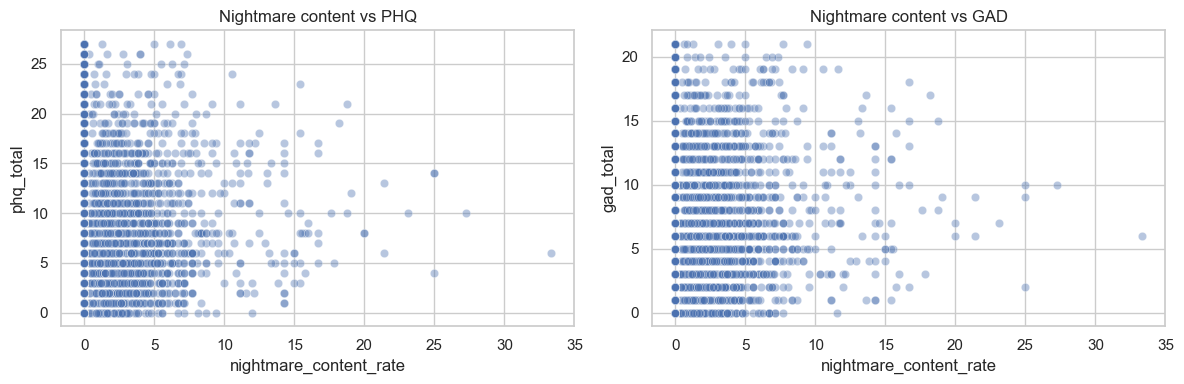

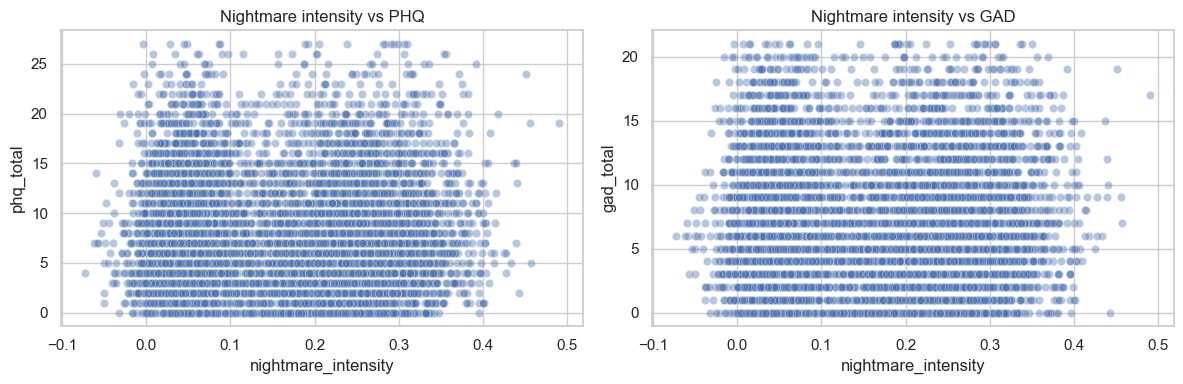

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(
    ax=axes[0], data=raw, x="nightmare_content_rate", y="phq_total", alpha=0.4
)
axes[0].set_title("Nightmare content vs PHQ")

sns.scatterplot(
    ax=axes[1], data=raw, x="nightmare_content_rate", y="gad_total", alpha=0.4
)
axes[1].set_title("Nightmare content vs GAD")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(ax=axes[0], data=raw, x="nightmare_intensity", y="phq_total", alpha=0.4)
axes[0].set_title("Nightmare intensity vs PHQ")

sns.scatterplot(ax=axes[1], data=raw, x="nightmare_intensity", y="gad_total", alpha=0.4)
axes[1].set_title("Nightmare intensity vs GAD")
plt.tight_layout()
plt.show()

## 7. Next steps
- Swap in richer lexicons (LIWC, NRC Emotion) and clinical dictionaries.
- Try non-linear models (Random Forest, XGBoost) and mixed-effects to handle repeated measures.
- Add covariates (sleep quality, demographics) to adjust estimates.